#### Create Pipeline

To make a geospatial live service, we have to make sure the inference input is exactly the same as training's dataset.

This standardization solves and bridges live data ingestion with various models input specification. NO MORE GLUE CODE!

The created pipeline can be used to create training dataset, granted you already have the anchor like semantic segmentation label for example.

In [1]:
%load_ext autoreload
%autoreload 2

from functools import cached_property

import numpy as np
import torch

from geosave_engine.geodata.tile import GeoTile
from geosave_engine.geodata.features import compute_ndvi
from geosave_engine.geodata.pipeline import GeoPipeline
from geosave_engine.geodata.stac import StacClient, StacSource

L2A_BANDS = [
    "B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08",
    "B09", "B11", "B12", "B8A", "SCL"
]

# DynamicWorld paper's model input set: all bands except B01/B8A/B09/B10 —
# fetched anyway (L2A_BANDS above) since cloud-mask derivation needs them,
# but the saved sentinel_2_l2a layer only carries what the model actually
# takes. odc-stac already resamples every band onto one geobox (bilinear by
# default, matching the paper) at StacSource.load time — no separate
# upscaling step needed here.
DW_MODEL_BANDS = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"]

# https://doi.pangaea.de/10.1594/PANGAEA.933475
DW_CLASS_MAP = { 
    0: "No Data",
    1: "Water",
    2: "Trees",
    3: "Grass",
    4: "Flooded Vegetation",
    5: "Crops",
    6: "Scrub",
    7: "Built Area",
    8: "Bare Ground",
    9: "Snow and Ice",
    10: "Cloud",
}

DW_COLOR_MAP = {
    0: "#000000",
    1: "#419bdf",
    2: "#397d49",
    3: "#88b053",
    4: "#7a87c6",
    5: "#e49635",
    6: "#dfc35a",
    7: "#c4281b",
    8: "#a59b8f",
    9: "#f0f0f0",
    10: "#d3d3d3"
}

In [3]:
class Pipeline(GeoPipeline):
    """Sentinel-2 imagery + cloud/shadow mask + NDVI for one anchor.

    This pipeline is a concrete example of how to use GeoPipeline to build a
    multi-layer sample from a single anchor. It fetches Sentinel-2 L1C imagery
    from the Copernicus Data Space Ecosystem STAC endpoint, derives a cloud/shadow mask 
    and NDVI from it, and returns a dict of GeoTile layers.
    """
    @cached_property
    def sources(self) -> dict[str, StacSource]:
        stac_client = StacClient.planetary_computer()
        # temporal_slots=1 because dynamicworld dataset is per scene
        return {
            "sentinel_2_l2a": stac_client.source(
                "sentinel-2-l2a", bands=L2A_BANDS, max_nodata_fraction=0.1, temporal_slots=1
            )
        }

    def preprocess(self, raw: dict[str, GeoTile]) -> dict[str, GeoTile]:
        s2 = raw["sentinel_2_l2a"]
        # temporal_slots=1 on the source (see `sources` above) — exactly one
        # scene per sample, so drop straight to (band, y, x)
        ds = s2.data.isel(time=0)

        ndvi = compute_ndvi(nir=ds.sel(band="B08").values, red=ds.sel(band="B04").values).astype(np.float32)

        s2_tile = (
            s2.with_data(s2.data.sel(band=DW_MODEL_BANDS))
            .with_metadata(
                {"description": f"Sentinel-2 L2A imagery ({len(DW_MODEL_BANDS)} bands, DynamicWorld input set)"}
            )
            .with_plot_meta(
                rgb_bands=("B04", "B03", "B02")
            )
        )

        ndvi_tile = s2.with_np(ndvi).with_metadata(
            {"description": "Normalized Difference Vegetation Index"}
        )

        # 0 = No Data, 1 = Saturated/Defective, 2 = Dark Area Pixels, 3 = Cloud Shadows,
        # 4 = Vegetation, 5 = Bare Soils, 6 = Water, 7 = Unclassified, 8 = Clouds Medium Probability, 
        # 9 = Clouds High Probability, 10 = Thin Cirrus, 11 = Snow or Ice

        mask = (ds.sel(band="SCL").values == 3) | (ds.sel(band="SCL").values == 8) | (ds.sel(band="SCL").values == 9)
        mask = mask.astype(np.uint8)  # 0=clear, 1=cloud/shadow
        
        mask_tile = (
            s2.with_np(mask).with_metadata(
                {"description": "Mask, 0=clear, 1=cloud/shadow"}
            )
            .with_plot_meta(
                class_map={0: "Clear", 1: "Cloud/Shadow"}, color_map={0: "#FFFFFF", 1: "#000000"})
        )
        
        return {
            "sentinel_2_l2a": s2_tile,
            "ndvi": ndvi_tile,
            "mask": mask_tile
        }

    def context(self, tiles: dict[str, GeoTile]) -> dict[str, torch.Tensor]:
        """PrithviTL's + Clay's raw forward() inputs for this sample.

        Keys mirror real forward() param names: `temporal_coords`/
        `location_coords` for `PrithviTL.forward_pyramid`, `time`/
        `latlon` for `Clay.forward`. Clay doesn't require these as ctx
        keys, so they sit unused in a Clay chain — harmless, `ContextChain`
        only pulls what a stage's own forward declares.

        Args:
            tiles: Layer name to GeoTile map — same sample `preprocess` built.

        Returns:
            {
                "temporal_coords": (1, 2) float32, (year, day_of_year), 0-indexed,
                "location_coords": (2,) float32, (lat, lon) degrees,
                "time": (2,) float32, raw (iso_week, hour),
                "latlon": (2,) float32, raw (lat, lon) degrees,
            }
        """
        tile = tiles["sentinel_2_l2a"]
        lon, lat = tile.centroid
        acquired = tile.times[0]
        day_of_year = acquired.timetuple().tm_yday - 1  # tm_yday is 1-indexed; Prithvi wants 0-indexed
        return {
            "temporal_coords": torch.tensor([[acquired.year, day_of_year]], dtype=torch.float32), # (1, 2)
            "location_coords": torch.tensor([lat, lon], dtype=torch.float32), # (2,)
            "time": torch.tensor([acquired.isocalendar().week, acquired.hour], dtype=torch.float32), # (2,)
            "latlon": torch.tensor([lat, lon], dtype=torch.float32), # (2,)
        }


date:  (datetime.datetime(2019, 7, 13, 0, 0), datetime.datetime(2019, 7, 13, 23, 59, 59, 999999))


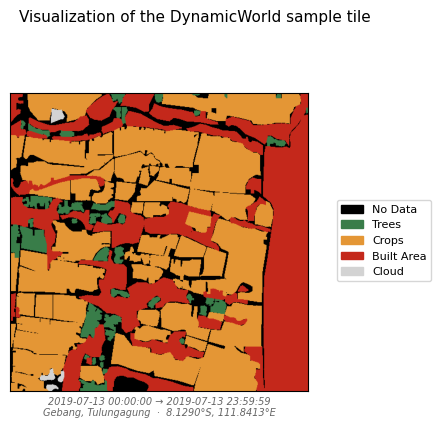

In [24]:
from geosave_engine.geodata.tile import GeoTile

tile_path = "data/dw_label/dw_111.8412562864_-8.1289167721-20190713.tif"
tile = GeoTile.from_geotiff(tile_path).with_plot_meta(class_map=DW_CLASS_MAP, color_map=DW_COLOR_MAP)
tile.plot(title="Visualization of the DynamicWorld sample tile")
print("date: ", tile.datetime) # this is the anchor for date range

[########################################] | 100% Completed | 8.32 sms


(<Figure size 1200x460 with 4 Axes>,
 array([[<Axes: title={'center': 'sentinel_2_l2a'}, xlabel='2019-07-13 02:35:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>,
         <Axes: title={'center': 'ndvi'}, xlabel='2019-07-13 02:35:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>,
         <Axes: title={'center': 'mask'}, xlabel='2019-07-13 02:35:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>]],
       dtype=object))

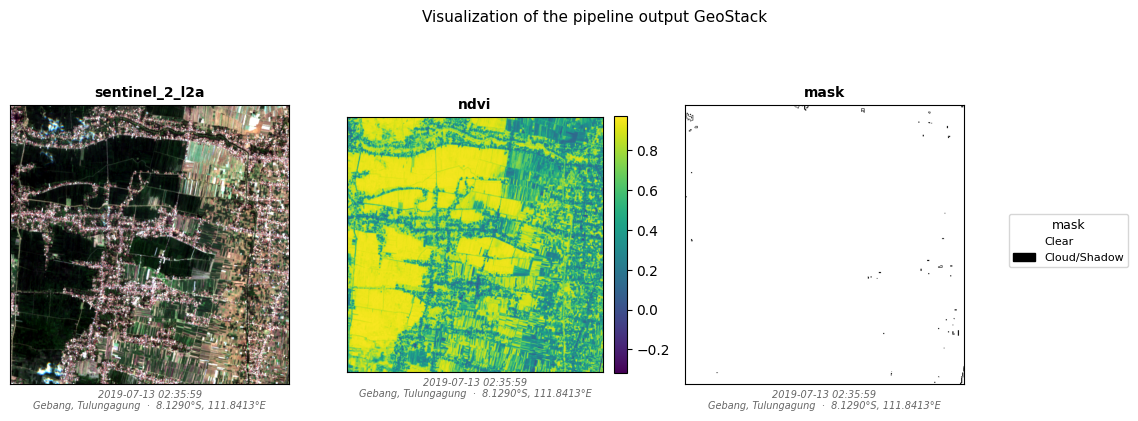

In [25]:
pipeline = Pipeline()

ingest_iter = pipeline.ingest(tile.to_anchor())

# This is a bit weird, but on inference, the request is AOI and date range
# Within that date range, it consist of multiple scenes, and the pipeline yields a GeoStack for each scene
# If we make a reference to a tiff files with datetime granularity of a day, 
# we know that first yielded GeoStack is the one we want

stack = next(ingest_iter)
stack.plot(title="Visualization of the pipeline output GeoStack")

(<Figure size 1600x460 with 5 Axes>,
 array([[<Axes: title={'center': 'sentinel_2_l2a'}, xlabel='2019-07-13 02:35:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>,
         <Axes: title={'center': 'ndvi'}, xlabel='2019-07-13 02:35:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>,
         <Axes: title={'center': 'mask'}, xlabel='2019-07-13 02:35:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>,
         <Axes: title={'center': 'dynamicworld'}, xlabel='2019-07-13 00:00:00 → 2019-07-13 23:59:59\nGebang, Tulungagung  ·  8.1290°S, 111.8413°E'>]],
       dtype=object))

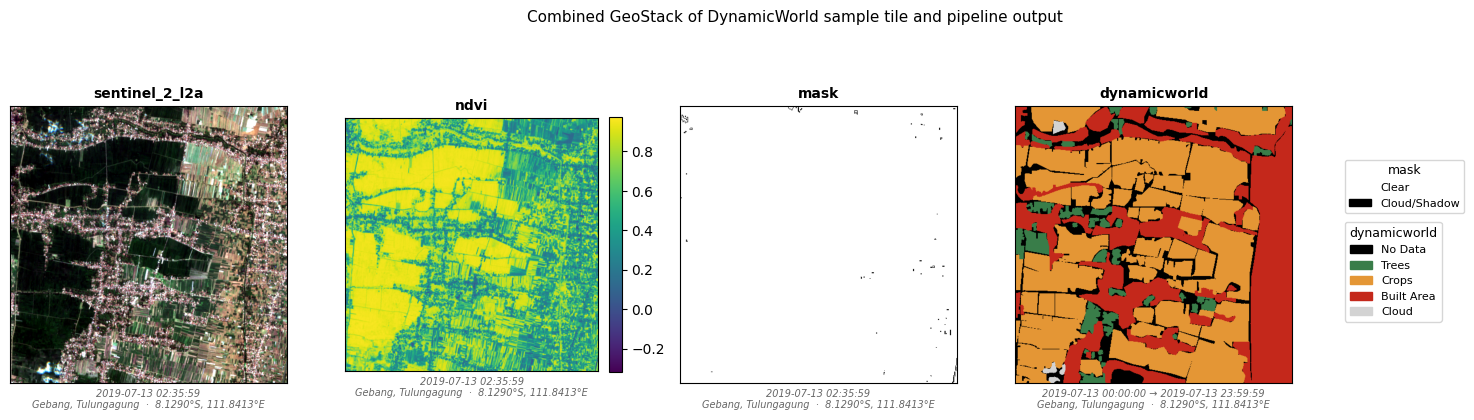

In [26]:
from geosave_engine.geodata.tile import GeoStack

# you can append geotiles and geostack
# kwargs are layer names, values are GeoTile instances
combined_stack = GeoStack(stack, dynamicworld=tile) 
combined_stack.plot(
    title="Combined GeoStack of DynamicWorld sample tile and pipeline output"
)

In [8]:
# you can save geostack to .geostack file (it is just a regular folder)
# geostack consist of zarr files
# use this to build dataset for training, or to save intermediate results for later use

combined_stack.save("data/dw_dataset/combined_stack.geostack")

geostack = GeoStack.load("data/dw_dataset/combined_stack.geostack")

#### Building Dataset

Use pipeline to build dataset for offline training

In [9]:
from pathlib import Path

pipeline = Pipeline()

for p in Path("data/dw_label").rglob("*.tif"):
    dw = GeoTile.from_geotiff(p).with_plot_meta(class_map=DW_CLASS_MAP, color_map=DW_COLOR_MAP)
    stack = next(pipeline.ingest(dw.to_anchor())) # the first yielded GeoStack is the one we want
    combined_stack = GeoStack(stack, dynamicworld=dw)
    # if you want to save stac metadata for each sample, you can specify the layer names here
    combined_stack.save(f"data/dw_dataset/{p.stem}.geostack", save_stac=["sentinel_2_l2a"]) 

[########################################] | 100% Completed | 2.53 sms
[########################################] | 100% Completed | 6.18 sms
[########################################] | 100% Completed | 3.55 sms


#### Ingest for Inference

For inference you can directly create the tensor for your model without needing torch Dataset

In [16]:
from geosave_engine.geodata.pipeline import source_from_dict

api_request ={
    'type': 'coordinate',
    'lat': -6.2088,
    'lon': 106.8456,
    'datetime': '2026-01', # lets query for the entirity of January 2026
    'area_m': 10000,
    'resolution': 10,
    'tile_size_px': 500 # autimatically chunk the request into 500x500 px, so the ingestion is not too huge crashing system memory
}

source = source_from_dict(api_request)
anchors = list(source.to_anchors())
anchors

[GeoAnchor(bbox=(699207.1688564343, 9313358.339245755, 704207.1688564343, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={}),
 GeoAnchor(bbox=(704207.1688564343, 9313358.339245755, 709207.1688564343, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={}),
 GeoAnchor(bbox=(699207.1688564343, 9308358.339245755, 704207.1688564343, 9313358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={}),
 GeoAnchor(bbox=(704207.1688564343, 9308358.339245755, 709207.1688564343, 9313358.339245755), crs='EPSG:32748', datetime=2026-01-01 00:00:00–2026-01-31 23:59:59.999999, metadata={})]

In [21]:
# first chunk from the anchor, 
# tiles for the whole month of January 2026, ready for model forward
model_ctx = list(pipeline.ingest_to_tensor(anchors[0]))

print("Number of scenes in the anchor:", len(model_ctx))
model_ctx[0]  # first sample's context dict, ready for model forward

[########################################] | 100% Completed | 3.75 sms
[########################################] | 100% Completed | 5.67 sms
[########################################] | 100% Completed | 5.27 sms
[########################################] | 100% Completed | 4.26 sms
[########################################] | 100% Completed | 5.98 sms
[########################################] | 100% Completed | 6.50 sms
Number of scenes in the anchor: 6


{'sentinel_2_l2a': tensor([[[[8321, 8305, 8318,  ..., 8293, 8295, 8281],
           [8303, 8314, 8341,  ..., 8282, 8301, 8320],
           [8319, 8318, 8328,  ..., 8285, 8308, 8316],
           ...,
           [8325, 8332, 8349,  ..., 8238, 8217, 8234],
           [8312, 8348, 8367,  ..., 8233, 8228, 8219],
           [8336, 8340, 8361,  ..., 8230, 8225, 8224]],
 
          [[8260, 8258, 8266,  ..., 8230, 8233, 8233],
           [8280, 8282, 8268,  ..., 8236, 8241, 8241],
           [8260, 8249, 8252,  ..., 8256, 8255, 8245],
           ...,
           [8259, 8264, 8270,  ..., 8195, 8182, 8172],
           [8261, 8248, 8262,  ..., 8183, 8184, 8192],
           [8263, 8266, 8262,  ..., 8189, 8201, 8215]],
 
          [[8282, 8277, 8295,  ..., 8281, 8279, 8283],
           [8316, 8300, 8294,  ..., 8269, 8279, 8297],
           [8296, 8298, 8292,  ..., 8287, 8296, 8293],
           ...,
           [8330, 8341, 8350,  ..., 8245, 8228, 8218],
           [8339, 8344, 8349,  ..., 8227, 8231, 

In [19]:
from geosave_engine.geodata.datasets import stack_samples

# lets stack the samples into a single batch for model forward
input_tensor = stack_samples(model_ctx)
input_tensor.keys()

dict_keys(['temporal_coords', 'time', 'anchors', 'sentinel_2_l2a', 'latlon', 'location_coords', 'ndvi', 'mask'])

In [ ]:
input_tensor["sentinel_2_l2a"].shape  # (batch, temporal, band, y, x) only one scene per sample

torch.Size([6, 1, 9, 500, 500])

In [ ]:
# We also need to forward the anchors, so that we can map the model output back to the original anchor
input_tensor["anchors"]

{'ndvi': [GeoAnchor(bbox=(699207.1688564343, 9313358.339245755, 704207.1688564343, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-03 03:00:19.024000, metadata={'description': 'Normalized Difference Vegetation Index'}),
  GeoAnchor(bbox=(699207.1688564343, 9313358.339245755, 704207.1688564343, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-08 03:01:21.025000, metadata={'description': 'Normalized Difference Vegetation Index'}),
  GeoAnchor(bbox=(699207.1688564343, 9313358.339245755, 704207.1688564343, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-13 02:59:59.024000, metadata={'description': 'Normalized Difference Vegetation Index'}),
  GeoAnchor(bbox=(699207.1688564343, 9313358.339245755, 704207.1688564343, 9318358.339245755), crs='EPSG:32748', datetime=2026-01-18 03:00:41.025000, metadata={'description': 'Normalized Difference Vegetation Index'}),
  GeoAnchor(bbox=(699207.1688564343, 9313358.339245755, 704207.1688564343, 9318358.339245755), crs='EPSG:32748', dat